In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle as pkl
import pandas as pd
import numpy as np
import os
import mlacca_functions as mlcf

In [2]:
df = pd.read_csv('data\\csv_files\\new_vk_areas_with_pahs.csv')

plot_format = 'png'

models_dir = 'data\\models'
save_plots_dir = f'data\\plots\\decision_boundaries\\partial_3d_plots\\{plot_format}'

xlim = (0,1.8)
ylim = (.2,2.8)
zlim = (0,.8)

In [3]:
df.loc[np.argsort(df['N/C'])]

,category,formula,C,H,O,N,S,P,H/C,O/C,N/C,S/C,P/C,weights
6073,tannin,C45H34O18,45,34,18,0,0,0,0.755556,0.400000,0.000000,0.0,0.0,4.521577
6070,tannin,C45H36O16,45,36,16,0,0,0,0.800000,0.355556,0.000000,0.0,0.0,4.521577
6069,tannin,C45H36O16,45,36,16,0,0,0,0.800000,0.355556,0.000000,0.0,0.0,4.521577
6068,tannin,C30H26O11,30,26,11,0,0,0,0.866667,0.366667,0.000000,0.0,0.0,4.521577
6064,tannin,C15H14O6,15,14,6,0,0,0,0.933333,0.400000,0.000000,0.0,0.0,4.521577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2117,lipid,C4H10N2O2,4,10,2,2,0,0,2.500000,0.500000,0.500000,0.0,0.0,0.169924
2124,lipid,C4H8N2O2,4,8,2,2,0,0,2.000000,0.500000,0.500000,0.0,0.0,0.169924
5791,peptide,C6H12ON4,6,12,1,4,0,0,2.000000,0.166667,0.666667,0.0,0.0,3.300923
2138,lipid,C3H8N2O2,3,8,2,2,0,0,2.666667,0.666667,0.666667,0.0,0.0,0.169924


In [4]:
model_files = os.listdir(models_dir)
model_dict = {}

for file in model_files:
        with open(f'{models_dir}\\{file}', "rb") as f:
                model_dict[file.replace('.pkl','')] = pkl.load(f)

In [5]:
def like_label(label:str):
    return f'{label.capitalize().replace('_',' ')}-like' if label != 'pah' else 'PAH-like'


def create_grid(density):
    xx, yy, zz = np.meshgrid(np.linspace(min(xlim),max(xlim), density),
                            np.linspace(min(ylim),max(ylim), density),
                            np.linspace(min(zlim),max(zlim), density),)

    xx = xx.flatten()
    yy = yy.flatten()
    zz = zz.flatten()
    grid = np.vstack((xx,yy,zz)).T

    return grid


def standard_3d_plot_features(ax,grid,label_fontsize=14):
    ax.set_xlabel('O/C',fontsize=label_fontsize,labelpad=15)
    ax.set_ylabel('H/C',fontsize=label_fontsize,labelpad=15)
    ax.set_zlabel('N/C',fontsize=label_fontsize,labelpad=8)

    mlcf.set_axis_ticks(grid[:,0],ax,axis='x',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(xlim),upper_lim=max(xlim))
    mlcf.set_axis_ticks(grid[:,1],ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(ylim),upper_lim=max(ylim))
    mlcf.set_axis_ticks(grid[:,2],ax,axis='z',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(zlim),upper_lim=max(zlim))

    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)

    ax.set_box_aspect(None, zoom=0.85)


def subplots_3d_molecclass(plot_list,ypred,legend_ax,label_fontsize=14):

    for plot in plot_list:

        idx = np.where([x in plot[2] for x in ypred])[0]
        plot[0].scatter(plot[1][:,0][idx],
                        plot[1][:,1][idx],
                        plot[1][:,2][idx],
                        c=[mlcf.vk_region_colours[x] for x in ypred[idx]],alpha=1,edgecolor='k',lw=.1)

        standard_3d_plot_features(plot[0],plot[1],label_fontsize=label_fontsize)

        plot[0].view_init(**plot[3])
        plot[0].set_title(**plot[4],fontsize=24)

        if plot[0] == legend_ax:
            for cat in np.unique(ypred):
                plot[0].scatter(10,10,10,c=mlcf.vk_region_colours[cat],alpha=1,edgecolor='k',lw=.1,label=like_label(cat),s=100)
            plot[0].legend(framealpha=1,bbox_to_anchor=(1,1.05), loc='upper left', borderaxespad=0, fontsize=18)


def subplots_3d_proba(plot_list:list[list[plt.Axes,np.ndarray,dict,dict]],
                      yproba,cmap='seismic',label_fontsize=14,**kwargs):
    
    norm_values = np.round([0,1],2)

    norm = mpl.colors.Normalize(vmin=norm_values[0],
                                vmax=norm_values[1])
    
    for plot in plot_list:
        ax_plot = plot[0].scatter(plot[1][:,0],
                                  plot[1][:,1],
                                  plot[1][:,2],
                                  c=yproba,cmap=cmap,norm=norm,**kwargs)
        
        standard_3d_plot_features(plot[0],plot[1],label_fontsize=label_fontsize)

        plot[0].view_init(**plot[2])
        plot[0].set_title(**plot[3],fontsize=24)

        if plot == plot_list[-1]:
            cbar = plot[0].get_figure().colorbar(ax_plot,ticks=np.linspace(norm_values[0],norm_values[1],5),location='bottom')
            cbar.set_label(label='Predicted compound class probability',size=14)



In [6]:
grid = create_grid(density=60)

## KNN

In [7]:
y_pred_knn = model_dict['knn'].predict(grid)

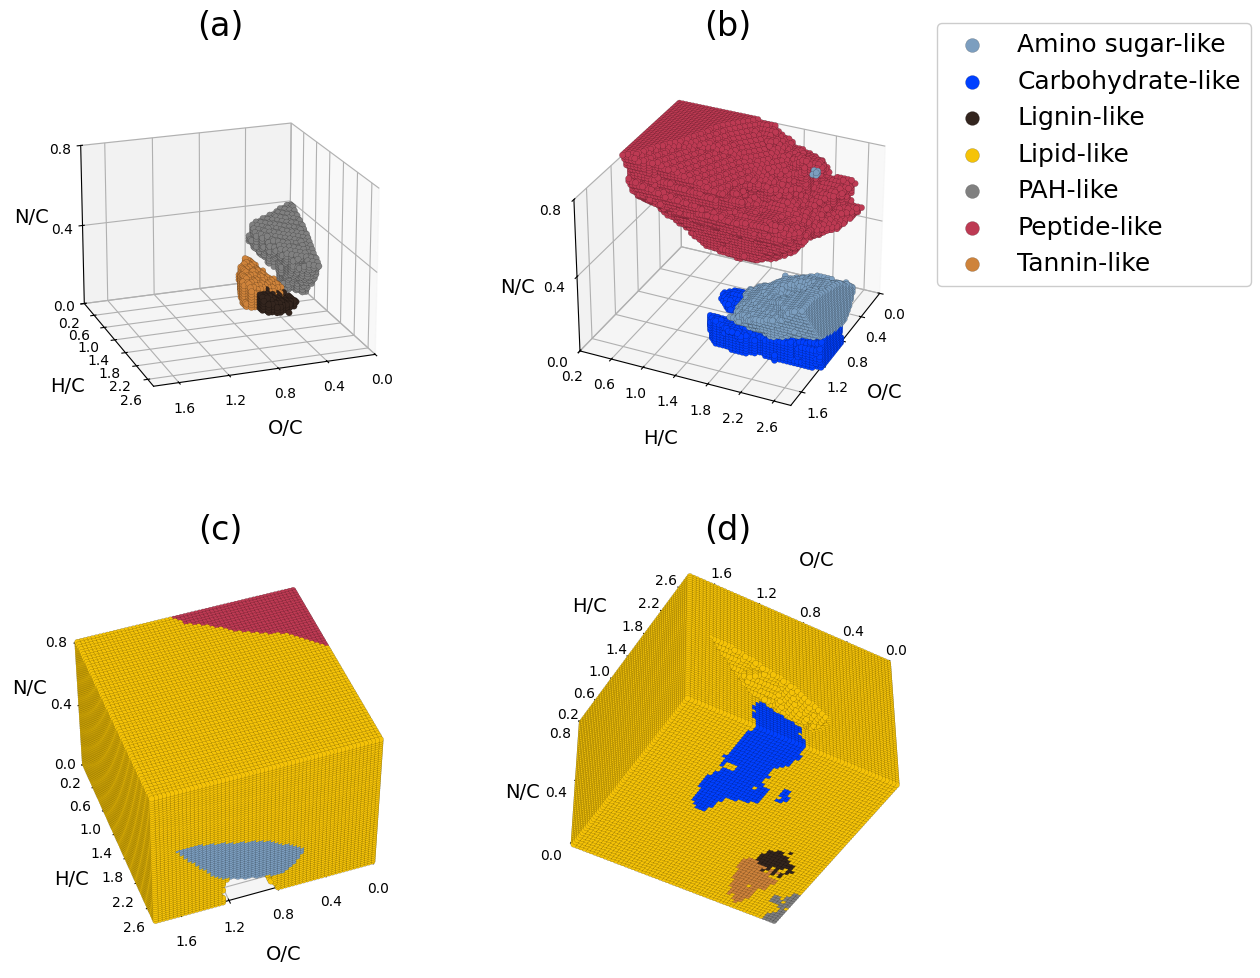

In [8]:
fig = plt.figure(figsize=(12,12)) # width, height

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

plot_list = [
    [ax1, grid, np.sort(['tannin','lignin','pah']), dict(elev=20, azim=70), dict(label='(a)')],
    [ax2, grid, np.sort(['carbohydrate','peptide','amino_sugar']), dict(elev=30, azim=25), dict(label='(b)')],
    [ax3, grid, np.sort(['lipid','peptide','amino_sugar']), dict(elev=45, azim=70), dict(label='(c)')],
    [ax4, grid, np.sort(['tannin','lignin','lipid','carbohydrate','pah']), dict(elev=-45, azim=60), dict(label='(d)')],    
    ]

subplots_3d_molecclass(plot_list,y_pred_knn,ax2)

fig.savefig(f'{save_plots_dir}\\knn.{plot_format}',dpi=600, facecolor = '#fff', bbox_inches='tight')

## GNB

In [9]:
y_pred_gnb = model_dict['gnb'].predict(grid)

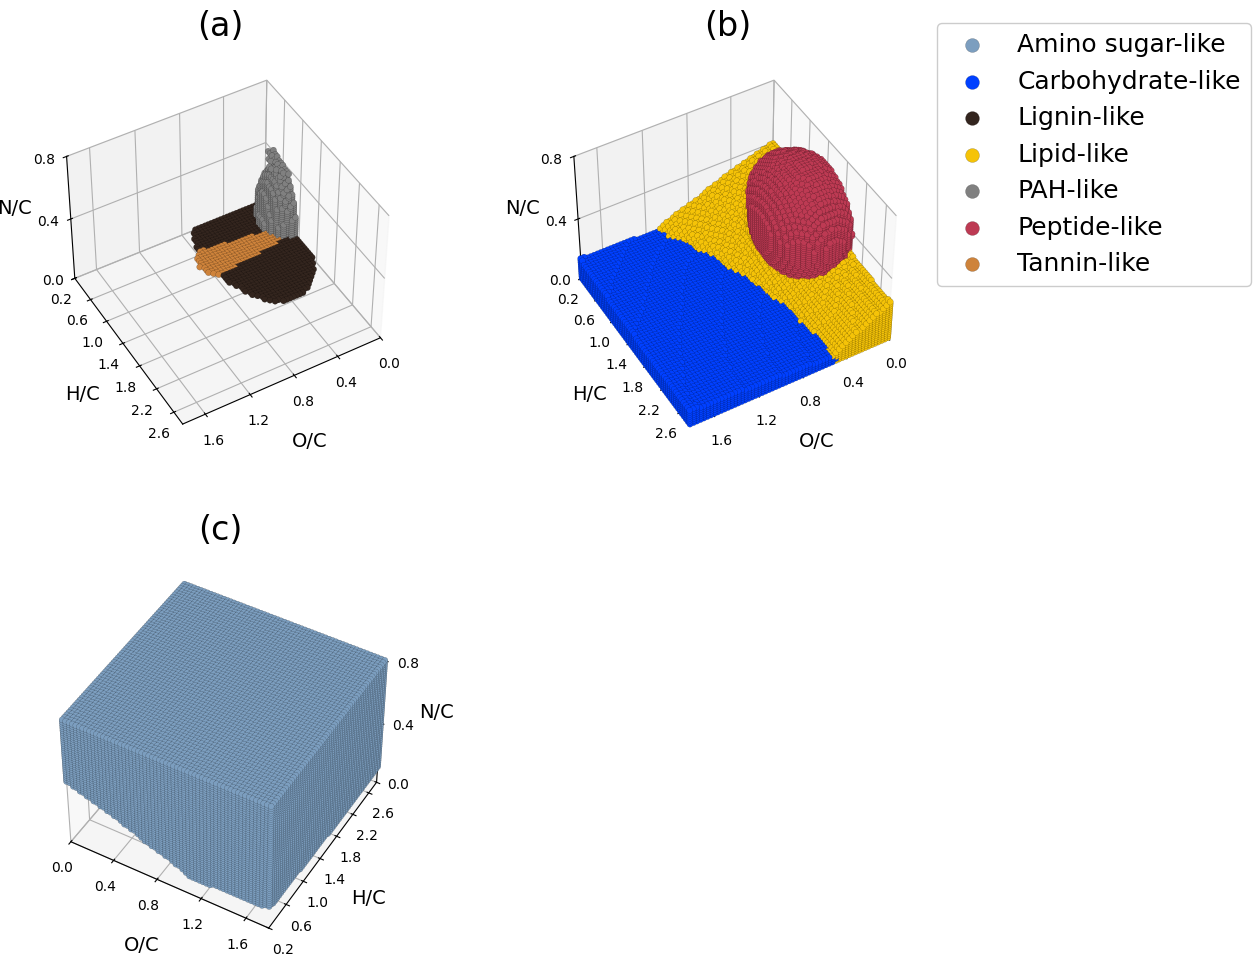

In [10]:
fig = plt.figure(figsize=(12,12)) # width, height

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')

plot_list = [
    [ax1, grid, np.sort(['tannin','lignin','pah']), dict(elev=45, azim=60), dict(label='(a)')],
    [ax2, grid, np.sort(['carbohydrate','lipid','peptide']), dict(elev=45, azim=60), dict(label='(b)')],
    [ax3, grid, np.sort(['amino_sugar']), dict(elev=45, azim=-60), dict(label='(c)')],#elev=-45, azim=210
    ]

subplots_3d_molecclass(plot_list,y_pred_gnb,ax2)

fig.savefig(f'{save_plots_dir}\\gnb.{plot_format}',dpi=600, facecolor = '#fff', bbox_inches='tight')

## Poly SVM

In [11]:
y_pred_svm_poly = model_dict['svm_poly'].predict(grid)

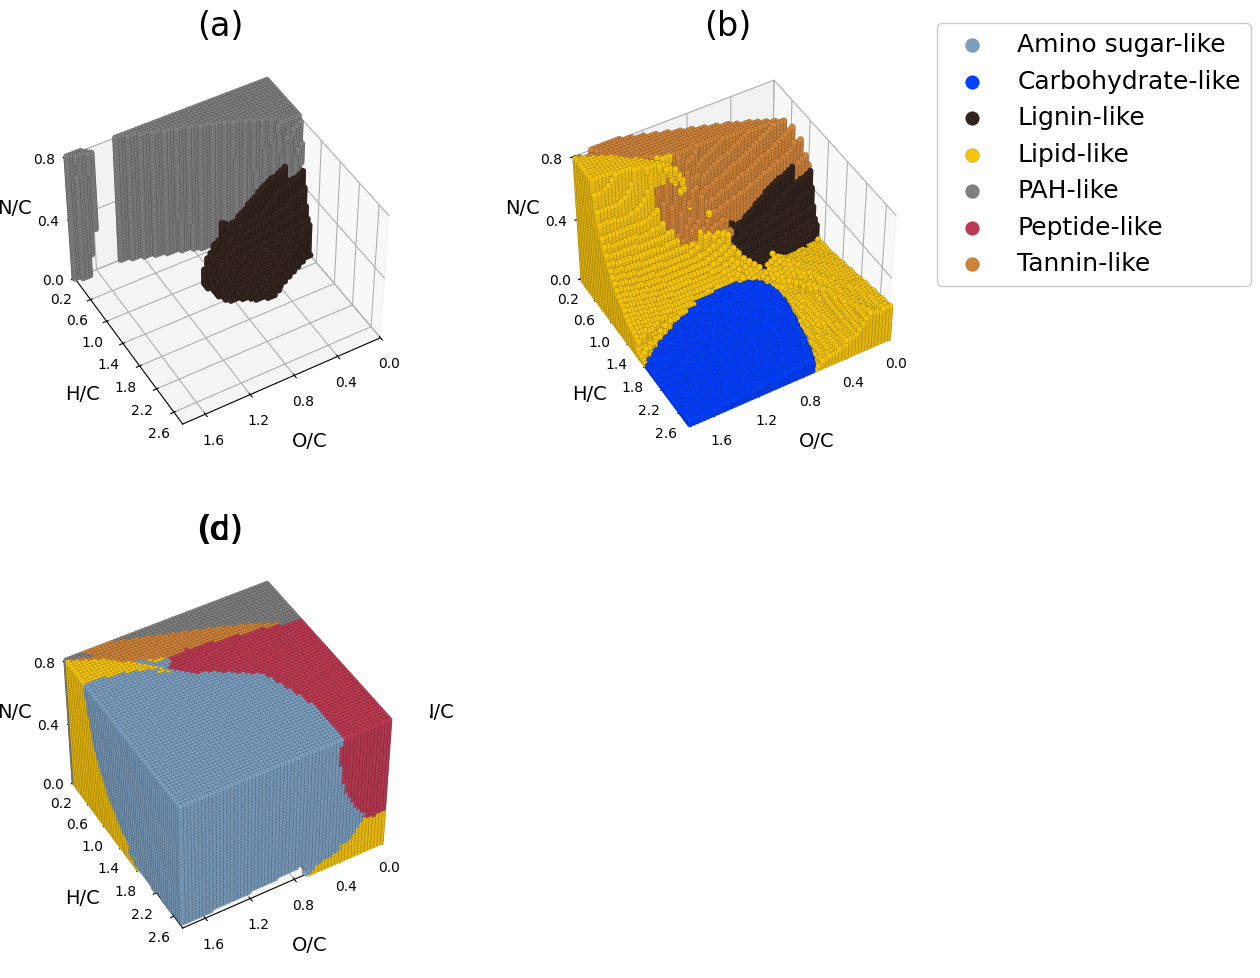

In [12]:
fig = plt.figure(figsize=(12,12)) # width, height

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(223, projection='3d')

plot_list = [
    [ax1, grid, np.sort(['lignin','pah']), dict(elev=45, azim=60), dict(label='(a)')],
    [ax2, grid, np.sort(['tannin','carbohydrate','lipid','lignin']), dict(elev=45, azim=60), dict(label='(b)')],
    [ax3, grid, np.sort(['peptide','amino_sugar','lipid','pah','tannin']), dict(elev=45, azim=-60), dict(label='(c)')],
    [ax4, grid, np.sort(['peptide','amino_sugar','lipid','pah','tannin']), dict(elev=45, azim=60), dict(label='(d)')],
    ]

subplots_3d_molecclass(plot_list,y_pred_svm_poly,ax2)

fig.savefig(f'{save_plots_dir}\\svm_poly.{plot_format}',dpi=600, facecolor = '#fff', bbox_inches='tight')

## RBF SVM

In [13]:
y_pred_svm_rbf = model_dict['svm_rbf'].predict(grid)

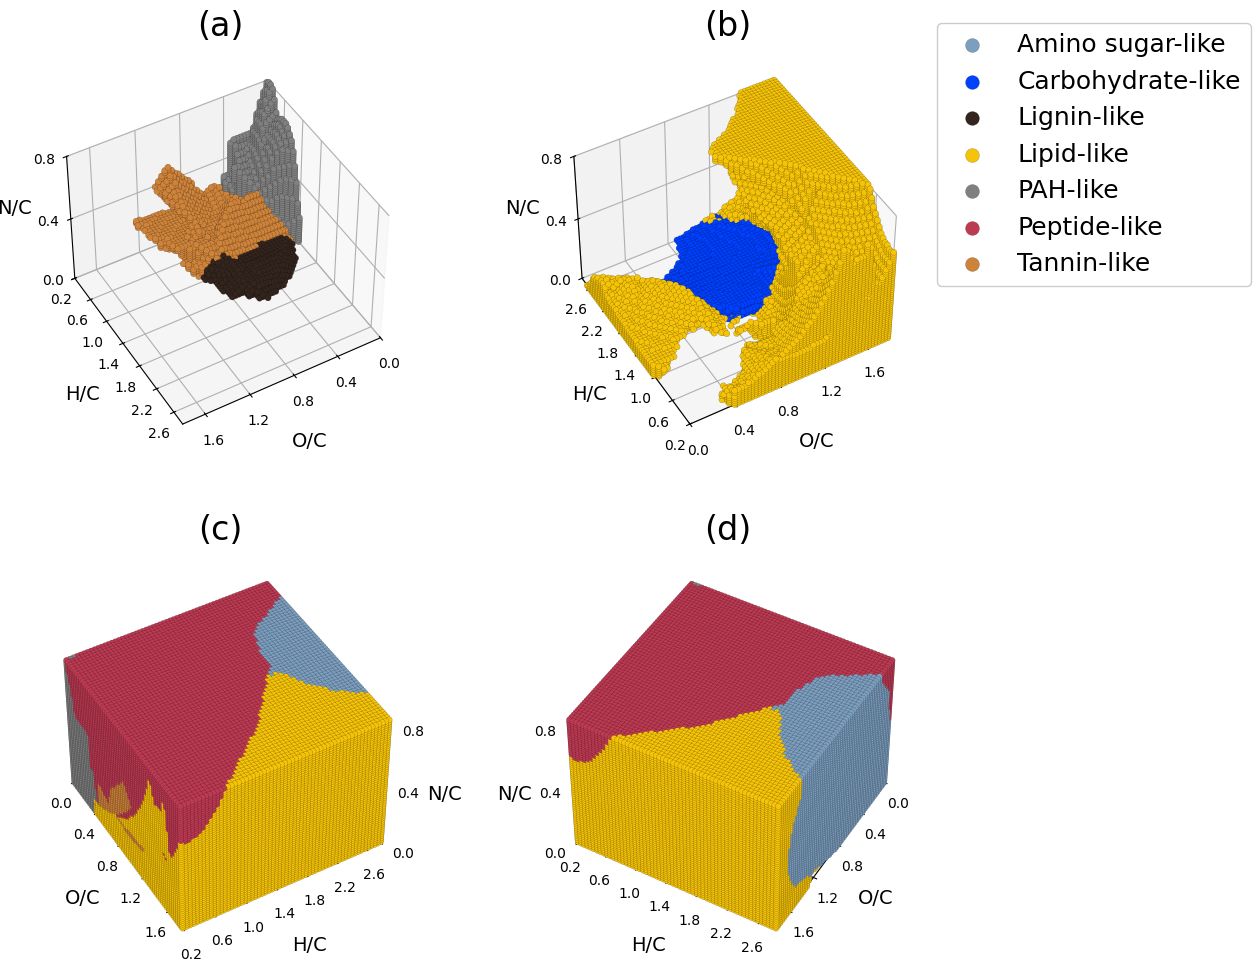

In [14]:
fig = plt.figure(figsize=(12,12)) # width, height

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

plot_list = [
    [ax1, grid, np.sort(['lignin','pah','tannin']), dict(elev=45, azim=60), dict(label='(a)')],
    [ax2, grid, np.sort(['carbohydrate','lipid']), dict(elev=45, azim=-120), dict(label='(b)')],
    [ax3, grid, np.sort(['peptide','amino_sugar','lipid','pah','tannin']), dict(elev=45, azim=-30), dict(label='(c)')],
    [ax4, grid, np.sort(['peptide','amino_sugar','lipid','pah','tannin']), dict(elev=45, azim=30), dict(label='(d)')],
    ]

subplots_3d_molecclass(plot_list,y_pred_svm_rbf,ax2)

fig.savefig(f'{save_plots_dir}\\svm_rbf.{plot_format}',dpi=600, facecolor = '#fff', bbox_inches='tight')